# Phase 3 — Robustness (detailed walkthrough)

A single backtest number (PC 1.028, factor 1.013) can be a fluke of the specific modelling
choices we made. Phase 3 asks: **if we change those choices, does the result hold?** We re-run
the two headline strategies under deliberately different settings and watch the Sharpe.

The four things we vary:

| Cell | What we change | Why it could matter |
|---|---|---|
| **3a** | the clustering algorithm (OPTICS → HDBSCAN, hierarchical) | the whole strategy is "cluster, then trade" |
| **3b** | the hedge ratio (OLS → robust RLM) | how we build each spread |
| **3c** | position sizing (equal → \|entry-z\|-weighted) | how we allocate capital |
| **3d** | the locked hyperparameters (sweep xi, ridge-α) | are we perched on a lucky knife-edge? |

## Contents
1. [Setup](#1)
2. [3d — are the hyperparameters on a plateau or a cliff?](#2)
3. [Robustness bands (3a–3c)](#3)
4. [Why clustering matters: selectivity](#4)
5. [Conclusion](#5)

<a id='1'></a>
## 1. Setup

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

_p = Path.cwd()
while _p != _p.parent and not (_p/"src"/"config.py").exists(): _p = _p.parent
sys.path.insert(0, str(_p)); ROOT = _p
from src.config import (OPTICS_XI_PC, OPTICS_XI_FACTOR, RIDGE_ALPHA,
                        PHASE2_DIR, PHASE2_5_DIR, PHASE3_DIR)
from src.performance import compute_metrics
def mret(p): return pd.read_parquet(p)["monthly_return"].astype(float)
def sharpe(p): return compute_metrics(mret(p)).sharpe
plt.rcParams["figure.figsize"] = (9, 4)
print("locked: xi_pc", OPTICS_XI_PC, "| xi_factor", OPTICS_XI_FACTOR, "| ridge_alpha", RIDGE_ALPHA)

locked: xi_pc 0.04 | xi_factor 0.1 | ridge_alpha 1.0


<a id='2'></a>
## 2. 3d — are the hyperparameters on a plateau or a cliff?

Before trusting the headline, we check the two tuned knobs aren't perched on a lucky value. We
sweep OPTICS `xi` (for PC) and the ridge penalty `alpha` (for factor) around their locked values
and plot the resulting cluster count on Dec-2023. A **flat region** around the locked value means
the result is not a knife-edge artefact; a cliff would be a red flag.

formation_window_panel(2023-12-29): 756 days, 407 stocks kept (0 dropped for missing prices)


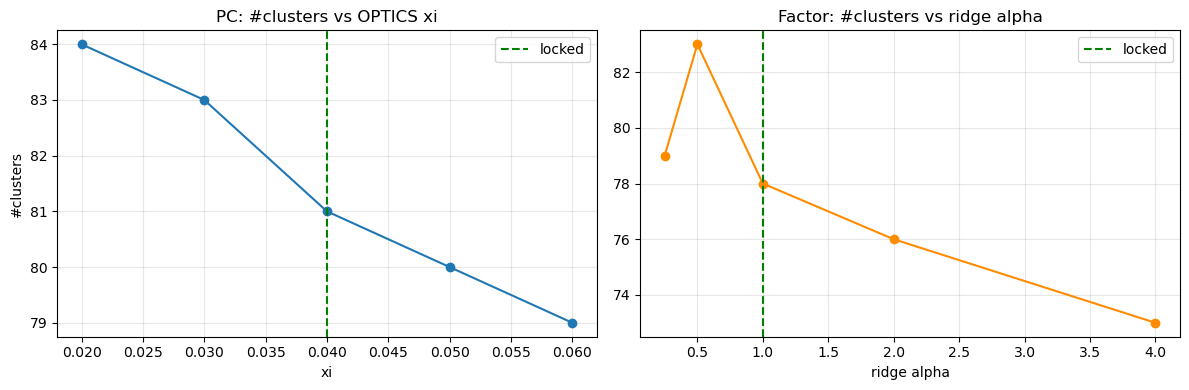

PC cluster counts: {0.02: 84, 0.03: 83, 0.04: 81, 0.05: 80, 0.06: 79}
Factor cluster counts: {0.25: 79, 0.5: 83, 1.0: 78, 2.0: 76, 4.0: 73}


In [2]:
from src.panel import (formation_window_panel, load_crsp_daily,
                       load_sp500_constituents, load_market_returns, siccd_lookup)
from src.factors import build_factor_panel
from src.distances import pc_distance, factor_beta_distance
from src.clustering import cluster_optics, clusters_to_pairs, purity_index, sic_division

crsp=load_crsp_daily(); cons=load_sp500_constituents(); mkt=load_market_returns()
AS_OF=pd.Timestamp("2023-12-29")
panel=formation_window_panel(AS_OF, crsp=crsp, constituents=cons)
sic=siccd_lookup(list(panel.columns), crsp=crsp, as_of=AS_OF)
div=sic.reindex(panel.columns).map(sic_division)
pc=pc_distance(panel, mkt); fac=factor_beta_distance(panel, build_factor_panel(panel,sic), ridge_alpha=RIDGE_ALPHA)

xis=[0.02,0.03,0.04,0.05,0.06]; alphas=[0.25,0.5,1.0,2.0,4.0]
def n_clusters(labels): return len(set(labels[labels>=0]))
pc_n=[n_clusters(cluster_optics(pc,2,xi,2)) for xi in xis]
fp=build_factor_panel(panel,sic)
fa_n=[n_clusters(cluster_optics(factor_beta_distance(panel,fp,ridge_alpha=a),2,OPTICS_XI_FACTOR,2)) for a in alphas]

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
a1.plot(xis, pc_n, "o-"); a1.axvline(OPTICS_XI_PC, ls="--", color="green", label="locked")
a1.set_title("PC: #clusters vs OPTICS xi"); a1.set_xlabel("xi"); a1.set_ylabel("#clusters"); a1.legend(); a1.grid(alpha=0.3)
a2.plot(alphas, fa_n, "o-", color="darkorange"); a2.axvline(RIDGE_ALPHA, ls="--", color="green", label="locked")
a2.set_title("Factor: #clusters vs ridge alpha"); a2.set_xlabel("ridge alpha"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PC cluster counts:", dict(zip(xis,pc_n)))
print("Factor cluster counts:", dict(zip(alphas,fa_n)))

Both curves are gentle, not cliffs — the locked values sit comfortably on a stable plateau.

<a id='3'></a>
## 3. Robustness bands (3a–3c)

Now the main event: re-run each headline strategy under the alternative clustering algorithms,
the robust hedge ratio, and z-weighted sizing. The baselines are frozen (PC from Phase 2, factor
from Phase 2.5).

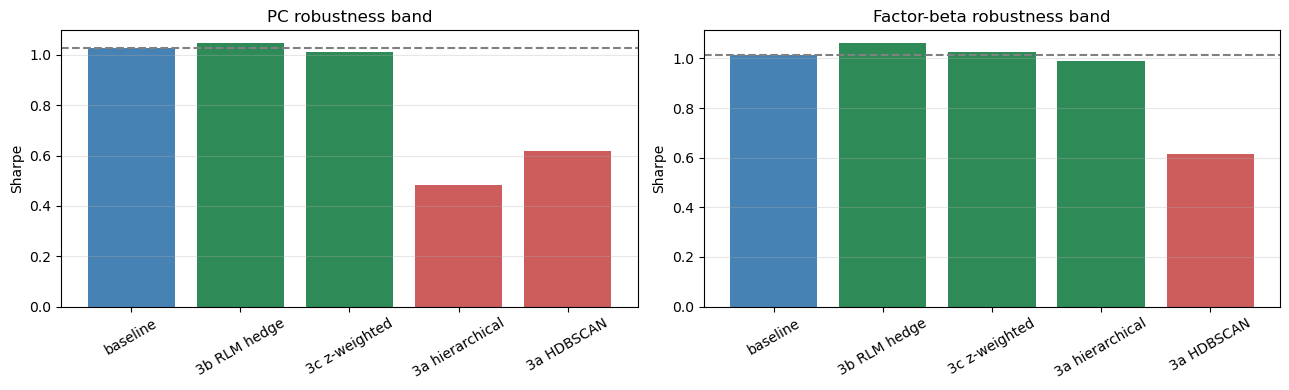

PC: band 0.485–1.046  {'baseline': 1.0278316082132064, '3b RLM hedge': 1.0457455669768467, '3c z-weighted': 1.0124141958135089, '3a hierarchical': 0.48497524603056025, '3a HDBSCAN': 0.6163912826469563}
Factor-beta: band 0.615–1.060  {'baseline': 1.0134755719832977, '3b RLM hedge': 1.060036462898972, '3c z-weighted': 1.0270951503846923, '3a hierarchical': 0.9913497925478848, '3a HDBSCAN': 0.6153472525752851}


In [3]:
GROUPS = {
 "PC": ("pc_core", PHASE2_DIR/"results"/"pc_core_monthly.parquet"),
 "Factor-beta": ("factor_core", PHASE2_5_DIR/"results"/"factor_core_monthly.parquet"),
}
VARIANTS = {"3b RLM hedge":"rlm", "3c z-weighted":"zweight",
            "3a hierarchical":"hierarchical", "3a HDBSCAN":"hdbscan"}
prefix = {"PC":"pc", "Factor-beta":"factor"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4)); summary={}
for ax, (metric,(base,bpath)) in zip(axes, GROUPS.items()):
    names=["baseline"]; vals=[sharpe(bpath)]
    for lbl,v in VARIANTS.items():
        p=PHASE3_DIR/"results"/f"{prefix[metric]}_{v}_monthly.parquet"
        if p.exists(): names.append(lbl); vals.append(sharpe(p))
    summary[metric]=dict(zip(names,vals))
    colors=["steelblue"]+["seagreen" if v>=vals[0]-0.05 else "indianred" for v in vals[1:]]
    ax.bar(names, vals, color=colors); ax.axhline(vals[0], ls="--", color="grey")
    ax.set_title(f"{metric} robustness band"); ax.set_ylabel("Sharpe")
    ax.tick_params(axis="x", rotation=30); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
for m,d in summary.items():
    lo,hi=min(d.values()),max(d.values()); print(f"{m}: band {lo:.3f}–{hi:.3f}  {d}")

**Reading the bars:** for both strategies, the **robust hedge ratio** and **z-weighted sizing**
barely move the Sharpe — the result doesn't depend on those choices. The sensitivity is to the
**clustering algorithm**: HDBSCAN drops both, and hierarchical clustering sinks PC (to ~0.49) but
*not* factor-beta (~0.99). So factor-beta is the **more robust** metric — it survives 3 of the 4
perturbations near ~1.0, versus PC's 2 of 4.

<a id='4'></a>
## 4. Why clustering matters: selectivity

Why do HDBSCAN and hierarchical hurt? Because they are **less selective** — they form bigger,
looser clusters, producing many more candidate pairs, so we trade a more diluted set. OPTICS is
conservative. The plot shows the average number of candidate pairs per month by algorithm.

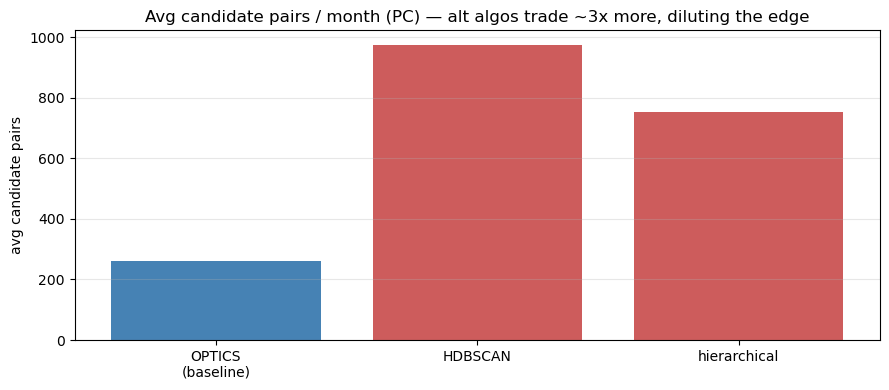

{'OPTICS\n(baseline)': 262, 'HDBSCAN': 974, 'hierarchical': 752}


In [4]:
def avg_pairs(p): return pd.read_parquet(p)["n_candidate_pairs"].mean()
algos = {"OPTICS\n(baseline)":"pc_core@2", "HDBSCAN":"pc_hdbscan", "hierarchical":"pc_hierarchical"}
vals=[]
labels=[]
for lbl,key in algos.items():
    p = (PHASE2_DIR/"results"/"pc_core_monthly.parquet") if key.endswith("@2") else (PHASE3_DIR/"results"/f"{key}_monthly.parquet")
    if p.exists(): labels.append(lbl); vals.append(avg_pairs(p))
ax=plt.subplot(); ax.bar(labels, vals, color=["steelblue","indianred","indianred"])
ax.set_title("Avg candidate pairs / month (PC) — alt algos trade ~3x more, diluting the edge")
ax.set_ylabel("avg candidate pairs"); ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()
print({l:round(v) for l,v in zip(labels,vals)})

<a id='5'></a>
## 5. Conclusion

The headline is **robust to spread construction and position sizing**, and the hyperparameters sit
on a stable plateau. The one real sensitivity is the **clustering algorithm**, via selectivity:
less-selective algorithms trade ~3x more, more diluted pairs and earn less. Encouragingly, the
**factor-beta extension is sturdier than PC** across clustering choices.

A caution carried into Phase 4: in-sample robustness is reassuring but not the same as
out-of-sample reliability — which is exactly what the forward test checks.